
#**Predicting Power Output of Large Scale Wave Energy Farms Using Spatial Layout Data**


## 1. Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load the Data
Importing `WEC_Sydney_49.csv` dataset from Google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DSI/WEC_Sydney_49.csv")
df.shape

(17964, 149)

## 3. Data Inspection


In [ ]:
# First 5 rows
df.head()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
0,1.00,1.00,0.00,70.00,1.00,140.00,50.00,198.00,401.00,1.00,...,71909.82,70674.49,70972.33,90957.03,90903.63,87876.82,79499.23,68880.39,0.78,4065416.61
1,598.00,0.00,595.82,77.69,593.70,150.00,549.00,198.00,798.00,0.00,...,68757.68,70665.50,69963.48,84511.25,85691.70,85211.51,76678.20,76119.53,0.76,3951216.37
2,198.00,0.00,197.46,75.19,192.94,150.00,87.64,198.00,398.00,0.00,...,73675.80,77808.44,73519.82,91436.35,88770.60,86632.78,77932.46,69343.12,0.78,4022640.78
3,598.00,0.00,596.97,69.41,592.69,143.80,549.00,198.00,398.00,200.00,...,68947.21,71668.05,69380.67,85191.27,84453.12,85300.41,78573.25,72527.16,0.75,3879223.41
4,198.00,0.00,197.18,79.83,192.97,150.00,89.53,198.00,398.00,0.00,...,78367.97,79075.06,74354.03,85254.75,86978.69,86951.65,77671.87,74901.38,0.77,3974691.24


In [ ]:
# Last 5 rows
df.tail()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
17959,1.00,198.00,50.00,198.00,100.00,198.00,150.00,198.00,201.00,1.00,...,74777.95,75328.19,72050.55,92155.56,89410.09,87942.24,82359.52,69035.90,0.79,4079797.83
17960,398.00,0.00,397.60,72.29,393.00,147.07,349.00,198.00,598.00,0.00,...,70923.77,70611.23,68249.45,90978.35,87013.51,84596.98,76776.71,75651.54,0.75,3909303.33
17961,1.00,1.00,1.00,51.00,1.00,101.00,1.00,151.00,648.00,1.00,...,83075.11,76547.45,76059.62,96899.02,91713.87,88308.28,75781.49,70417.64,0.79,4111341.29
17962,1.00,1.00,1.00,51.00,1.00,101.00,1.00,151.00,648.00,1.00,...,80868.59,76420.36,75312.25,95833.13,92514.46,88406.40,79531.50,70704.51,0.79,4100219.73
17963,198.00,0.00,196.79,73.55,197.18,147.45,149.00,198.00,398.00,0.00,...,70290.22,76572.72,77838.76,86024.36,86504.53,86728.45,79660.05,78190.24,0.77,4011000.25


In [ ]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17964 entries, 0 to 17963
Columns: 149 entries, X1 to Total_Power
dtypes: float64(149)
memory usage: 20.4 MB


## 4. Summary Statistics

In [ ]:
# Overall summary stats
df.describe()

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
count,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,...,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00
mean,138.86,3.72,142.89,66.75,148.17,129.35,114.38,179.51,498.46,4.90,...,75429.80,74536.67,72190.75,88630.87,87901.48,87100.34,79188.67,73231.32,0.78,4026608.46
std,167.91,28.40,166.60,26.71,166.47,35.94,150.75,33.73,187.32,32.83,...,4591.69,3177.05,3125.75,6203.80,4116.31,2669.57,2887.75,4419.35,0.01,70704.63
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,59476.59,62909.25,63097.18,58426.03,64699.35,63228.61,65675.24,63575.55,0.70,3625434.37
25%,1.00,0.00,1.00,51.00,1.00,101.00,1.00,151.00,398.00,0.00,...,72440.38,72435.04,69973.06,86452.09,86674.77,86183.59,77165.08,70034.37,0.77,3981419.87
50%,198.00,0.00,195.96,70.00,192.36,143.80,82.85,198.00,401.00,0.00,...,75256.94,74544.60,72208.78,89864.59,89040.17,87587.27,78924.36,73149.00,0.78,4034284.37
75%,198.00,1.00,197.11,75.65,193.70,150.00,149.00,198.00,598.00,1.00,...,78095.64,76572.72,74250.46,93273.41,90637.01,88578.23,80838.61,75713.18,0.79,4083746.22
max,1000.00,988.26,1000.00,989.65,1000.00,990.00,1000.00,990.00,1000.00,990.00,...,106876.87,107133.93,101385.03,99223.71,100955.35,103323.71,95130.39,96532.93,0.80,4145252.22


In [ ]:
# Focusing on the target variable
print('=== Total Power Output Summary ===')
print(f"Mean:    {df['Total_Power'].mean():,.0f} W")
print(f"Median:  {df['Total_Power'].median():,.0f} W")
print(f"Std Dev: {df['Total_Power'].std():,.0f} W")
print(f"Min:     {df['Total_Power'].min():,.0f} W")
print(f"Max:     {df['Total_Power'].max():,.0f} W")

=== Total Power Output Summary ===
Mean:    4,026,608 W
Median:  4,034,284 W
Std Dev: 70,705 W
Min:     3,625,434 W
Max:     4,145,252 W


In [ ]:
# Summary of individual power outputs (Power1 to Power49)
power_cols = [c for c in df.columns if c.startswith('Power') and c != 'Total_Power']
df[power_cols].describe()

,Power1,Power2,Power3,Power4,Power5,Power6,Power7,Power8,Power9,Power10,...,Power40,Power41,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49
count,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,...,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00,17964.00
mean,94882.07,85284.94,81216.33,76575.20,98986.09,90734.88,85456.43,79357.45,102193.40,95603.54,...,71306.22,77877.77,75429.80,74536.67,72190.75,88630.87,87901.48,87100.34,79188.67,73231.32
std,4147.01,4558.02,5000.28,4205.08,4045.22,5502.89,6548.21,5874.89,7470.38,8159.67,...,3686.04,6334.96,4591.69,3177.05,3125.75,6203.80,4116.31,2669.57,2887.75,4419.35
min,65985.09,68965.21,70427.90,63654.48,72359.55,66325.57,67094.91,59758.01,65764.39,63543.68,...,57815.79,55091.69,59476.59,62909.25,63097.18,58426.03,64699.35,63228.61,65675.24,63575.55
25%,93023.68,82411.64,77856.82,73925.87,96296.37,86897.66,80715.12,75276.39,100468.56,91073.73,...,69228.87,73642.06,72440.38,72435.04,69973.06,86452.09,86674.77,86183.59,77165.08,70034.37
50%,95161.50,85126.66,80698.71,76222.11,99590.33,90594.31,85134.88,79591.39,102600.20,94817.13,...,71316.12,77780.10,75256.94,74544.60,72208.78,89864.59,89040.17,87587.27,78924.36,73149.00
75%,96612.54,87811.13,83785.13,78849.86,101012.46,93253.32,88335.78,83730.11,107335.74,103001.17,...,73108.84,82196.55,78095.64,76572.72,74250.46,93273.41,90637.01,88578.23,80838.61,75713.18
max,108631.18,107749.27,108165.28,108541.97,108982.43,108571.97,108373.60,108346.78,110759.71,108633.02,...,98129.31,100243.82,106876.87,107133.93,101385.03,99223.71,100955.35,103323.71,95130.39,96532.93


## 5. Check for Missing Values

In [ ]:
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
print(f'Columns with missing values: {(missing > 0).sum()}')

# Show any columns that do have missing values
if missing.sum() > 0:
    print('\nColumns with missing data:')
    print(missing[missing > 0])
else:
    print('No missing values found — dataset is complete!')

Total missing values: 0
Columns with missing values: 0
No missing values found — dataset is complete!


#6. Check for duplicates

In [ ]:
df.duplicated().sum()


np.int64(13148)

In [ ]:
duplicates = df[df.duplicated()]

duplicates

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power42,Power43,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power
31,1.00,1.00,1.00,51.00,1.00,101.00,1.00,151.00,601.00,1.00,...,74568.16,77997.08,74154.58,89272.62,89877.37,87790.83,80610.05,69248.20,0.79,4110398.43
37,198.00,0.00,195.76,77.94,191.75,150.00,89.76,198.00,398.00,0.00,...,81008.48,75171.97,70954.27,94436.98,91675.18,88472.68,78406.32,72328.87,0.78,4039187.39
67,198.00,0.00,197.46,75.65,193.60,144.02,149.00,198.00,398.00,0.00,...,71985.48,69691.48,68470.55,80682.84,82923.38,84546.44,77856.36,76575.36,0.77,4002736.09
81,1.00,1.00,1.00,51.00,1.00,101.00,1.00,151.00,598.00,0.00,...,74063.18,75369.02,70896.78,87322.75,86885.05,87155.99,78393.50,71345.70,0.78,4053977.19
93,1.00,1.00,1.00,51.00,1.00,101.00,1.00,151.00,201.00,1.00,...,74714.58,75550.54,75328.34,91623.63,88479.75,88650.11,80066.00,72209.57,0.79,4082853.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17959,1.00,198.00,50.00,198.00,100.00,198.00,150.00,198.00,201.00,1.00,...,74777.95,75328.19,72050.55,92155.56,89410.09,87942.24,82359.52,69035.90,0.79,4079797.83
17960,398.00,0.00,397.60,72.29,393.00,147.07,349.00,198.00,598.00,0.00,...,70923.77,70611.23,68249.45,90978.35,87013.51,84596.98,76776.71,75651.54,0.75,3909303.33
17961,1.00,1.00,1.00,51.00,1.00,101.00,1.00,151.00,648.00,1.00,...,83075.11,76547.45,76059.62,96899.02,91713.87,88308.28,75781.49,70417.64,0.79,4111341.29
17962,1.00,1.00,1.00,51.00,1.00,101.00,1.00,151.00,648.00,1.00,...,80868.59,76420.36,75312.25,95833.13,92514.46,88406.40,79531.50,70704.51,0.79,4100219.73


In [ ]:
duplicate_counts = df.groupby(list(df.columns)).size().reset_index(name='count')

duplicate_counts['duplicates_only'] = duplicate_counts['count'] - 1

duplicate_counts = duplicate_counts.sort_values(by='duplicates_only', ascending=False)


duplicate_counts.head(10)

,X1,Y1,X2,Y2,X3,Y3,X4,Y4,X5,Y5,...,Power44,Power45,Power46,Power47,Power48,Power49,qW,Total_Power,count,duplicates_only
3441,198.00,0.00,197.60,70.41,193.21,148.96,149.00,198.00,398.00,0.00,...,70292.38,86203.38,85768.62,86615.31,77073.23,75445.31,0.77,4008086.42,161,160
2505,198.00,0.00,197.07,77.97,192.74,150.00,97.24,198.00,598.00,0.00,...,68989.66,86890.70,87391.91,85993.26,76093.59,71330.03,0.77,4011030.04,139,138
1260,1.00,198.00,50.00,198.00,100.00,198.00,150.00,198.00,201.00,1.00,...,72050.55,92155.56,89410.09,87942.24,82359.52,69035.90,0.79,4079797.83,138,137
1824,198.00,0.00,196.79,73.55,197.18,147.45,149.00,198.00,398.00,0.00,...,70104.56,86733.79,87923.24,89213.22,81837.43,75206.01,0.78,4019957.44,133,132
1433,198.00,0.00,195.76,77.94,191.75,150.00,89.76,198.00,398.00,0.00,...,70954.27,94436.98,91675.18,88472.68,78406.32,72328.87,0.78,4039187.39,123,122
2886,198.00,0.00,197.07,79.04,197.18,150.00,81.08,198.00,598.00,0.00,...,68568.44,86956.40,88093.66,86855.95,79035.69,71429.08,0.78,4031240.61,112,111
3157,198.00,0.00,197.46,75.21,197.18,150.00,82.51,198.00,598.00,0.00,...,68770.00,93639.04,89954.43,87327.17,75911.69,73267.20,0.78,4022547.86,96,95
3199,198.00,0.00,197.46,75.37,193.18,150.00,85.07,198.00,398.00,0.00,...,72922.40,77095.99,83439.38,86725.20,77197.84,78602.68,0.77,3997357.50,95,94
2679,198.00,0.00,197.07,78.26,192.89,150.00,82.16,198.00,598.00,0.00,...,69264.56,86458.00,86996.63,85502.43,74449.43,77849.38,0.78,4018202.98,87,86
2540,198.00,0.00,197.07,78.02,197.07,147.51,149.00,198.00,598.00,0.00,...,70444.25,85906.80,87582.37,87345.77,81269.80,75641.37,0.78,4027604.80,85,84


On analysis, it was observed that they were repeated spatial structures. So, dropping the duplicates to prevent bias and overfitting, allowing the model to learn broader patterns from 4,816 unique WEC performance records.

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

# Check new shape
print("New dataset shape:", df.shape)

New dataset shape: (4816, 149)


## 7. Exploratory Visualisations

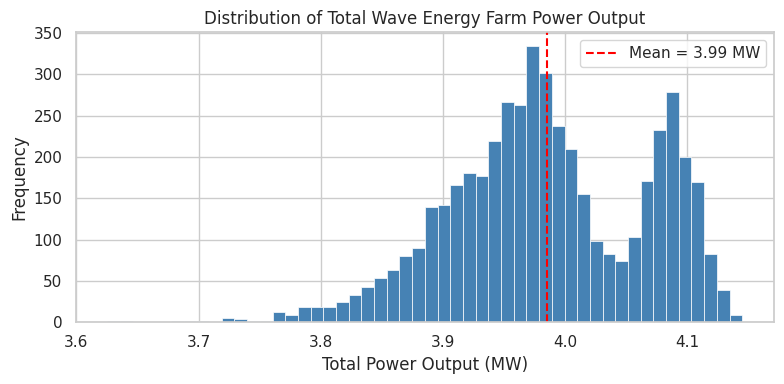

In [ ]:
# Distribution of Total Power Output
plt.figure(figsize=(8, 4))
plt.hist(df['Total_Power'] / 1e6, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.axvline(df['Total_Power'].mean() / 1e6, color='red', linestyle='--', linewidth=1.5,
            label=f"Mean = {df['Total_Power'].mean()/1e6:.2f} MW")
plt.xlabel('Total Power Output (MW)')
plt.ylabel('Frequency')
plt.title('Distribution of Total Wave Energy Farm Power Output')
plt.legend()
plt.tight_layout()

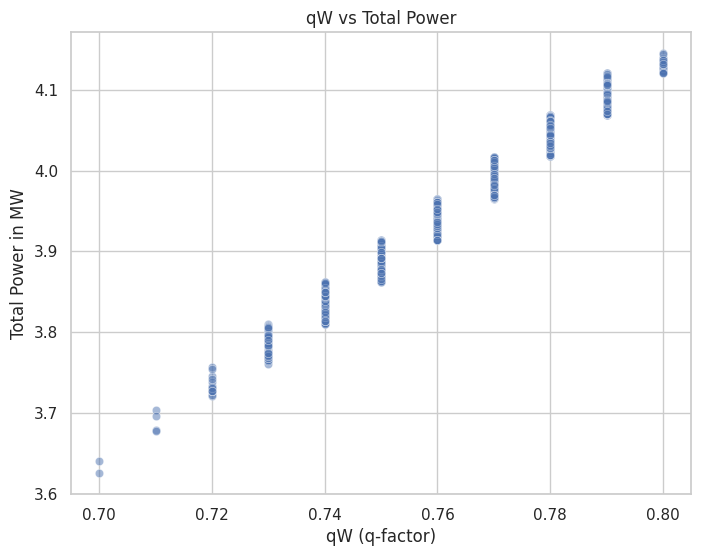

In [ ]:
# Scatter plot of qW vs Total Power
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['qW'], y=df['Total_Power'] / 1e6, alpha=0.5)

plt.xlabel('qW (q-factor)')
plt.ylabel('Total Power in MW')
plt.title('qW vs Total Power')

plt.show()

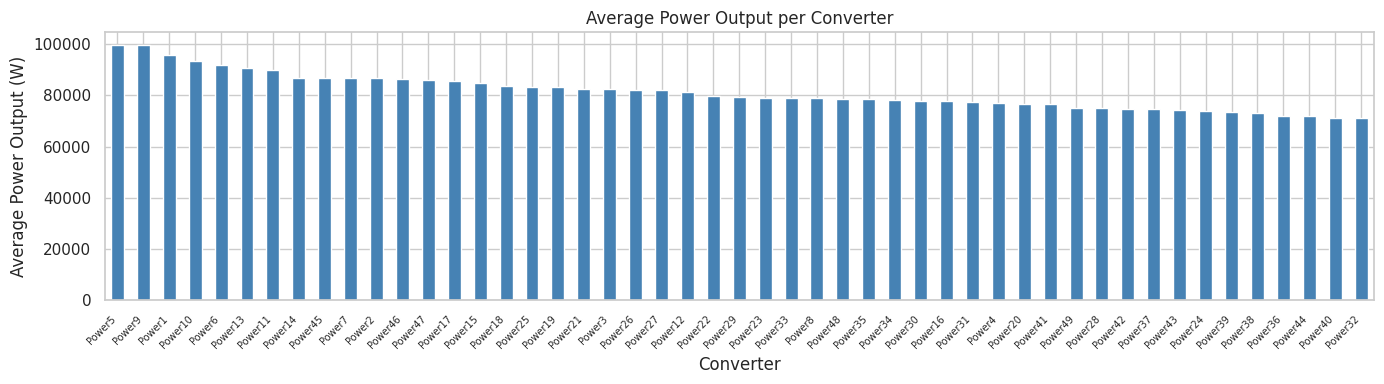

In [ ]:
# Average power output per converter
avg_power = df[power_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 4))
avg_power.plot(kind='bar', color='steelblue', edgecolor='white')
plt.xlabel('Converter')
plt.ylabel('Average Power Output (W)')
plt.title('Average Power Output per Converter')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

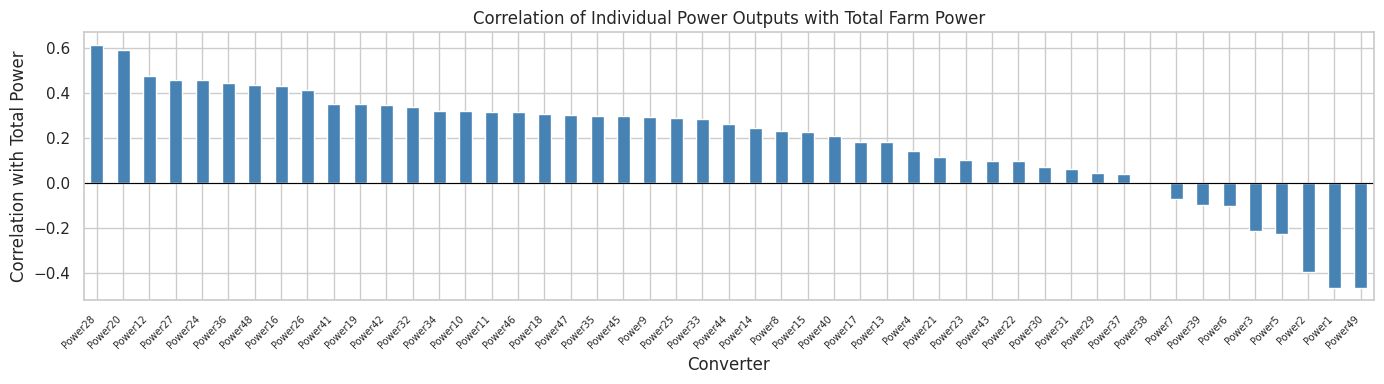

Top 5 most correlated converters:
Power28   0.61
Power20   0.59
Power12   0.47
Power27   0.46
Power24   0.46
Name: Total_Power, dtype: float64


In [ ]:
# Correlation of each individual power output with Total_Power
corr_with_target = df[power_cols + ['Total_Power']].corr()['Total_Power'].drop('Total_Power').sort_values(ascending=False)

plt.figure(figsize=(14, 4))
corr_with_target.plot(kind='bar', color='steelblue', edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Converter')
plt.ylabel('Correlation with Total Power')
plt.title('Correlation of Individual Power Outputs with Total Farm Power')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.tight_layout()
plt.show()

print('Top 5 most correlated converters:')
print(corr_with_target.head())

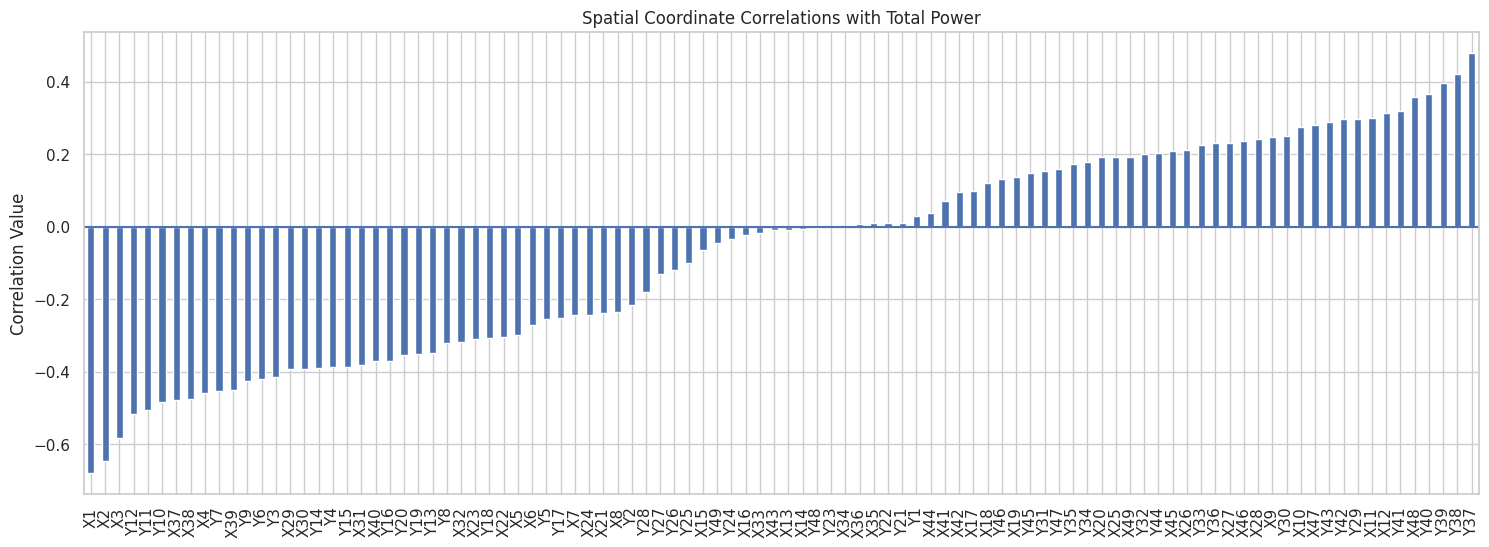

In [ ]:
# Plot showing coordinates and its relation with Total Power
x_cols = [col for col in df.columns if col.startswith('X')]
y_cols = [col for col in df.columns if col.startswith('Y')]

spatial_cols = x_cols + y_cols

coord_corr = df[spatial_cols + ['Total_Power']].corr()['Total_Power'].drop('Total_Power')
plt.figure(figsize=(18,6))

coord_corr.sort_values().plot(kind='bar')

plt.title("Spatial Coordinate Correlations with Total Power")
plt.ylabel("Correlation Value")
plt.axhline(0)  # important line to separate + and -

plt.show()

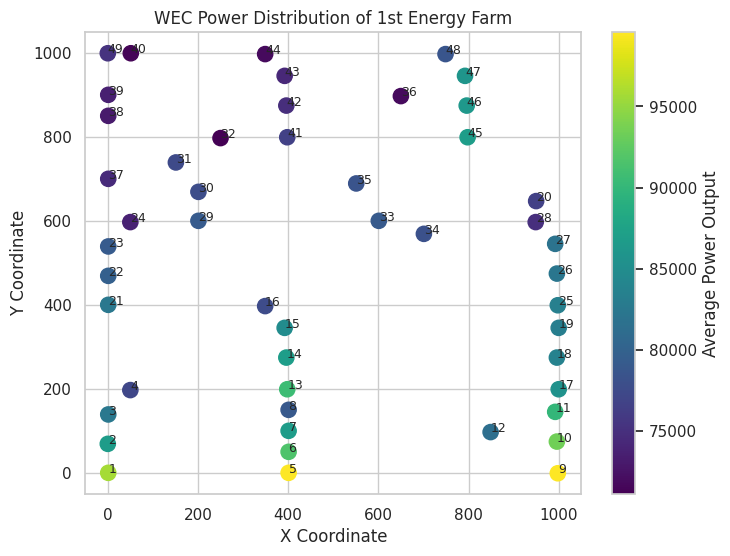

In [ ]:
x_cols = [f"X{i}" for i in range(1, 50)]
y_cols = [f"Y{i}" for i in range(1, 50)]

# Taking first row (1st wave farm layout)
x = df.loc[0, x_cols]
y = df.loc[0, y_cols]

# Computing average power for each WEC
power_cols = [f"Power{i}" for i in range(1, 50)]
avg_power = df[power_cols].mean()


plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x, y,
    c=avg_power,
    cmap='viridis',
    s=120
)

# Labeling each WEC
for i in range(len(x)):
    plt.text(x.iloc[i], y.iloc[i], str(i+1), fontsize=9)

plt.colorbar(scatter, label="Average Power Output")


plt.title("WEC Power Distribution of 1st Energy Farm")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid(True)
plt.show()

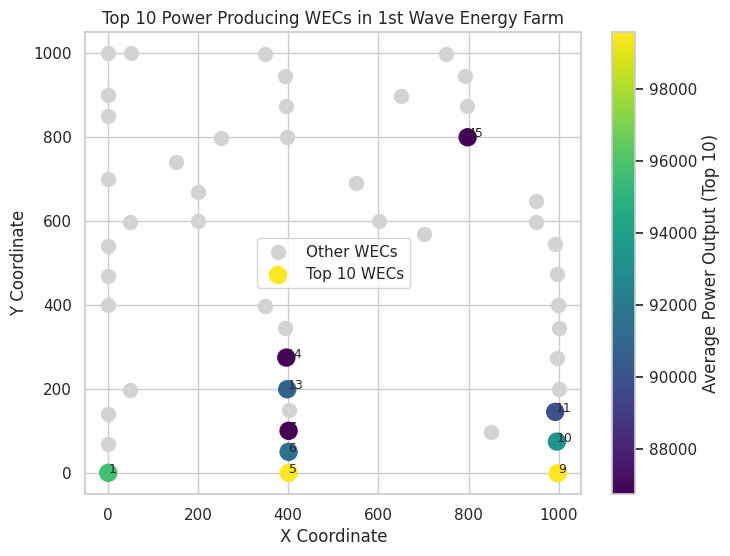

In [ ]:
# Top 10 WEC in 1st Farm layout
top_n = 10
top_wecs = avg_power.sort_values(ascending=False).head(top_n)

top_indices = [int(i.replace('Power',''))-1 for i in top_wecs.index]


plt.figure(figsize=(8,6))

plt.scatter(x, y, color='lightgrey', s=100, label='Other WECs')

scatter = plt.scatter(
    x.iloc[top_indices],
    y.iloc[top_indices],
    c=avg_power.iloc[top_indices],
    cmap='viridis',
    s=150,
    label='Top 10 WECs'
)

for i in top_indices:
    plt.text(x.iloc[i], y.iloc[i], str(i+1), fontsize=9)

plt.colorbar(scatter, label="Average Power Output (Top 10)")

plt.title("Top 10 Power Producing WECs in 1st Wave Energy Farm")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.legend()
plt.grid(True)
plt.show()

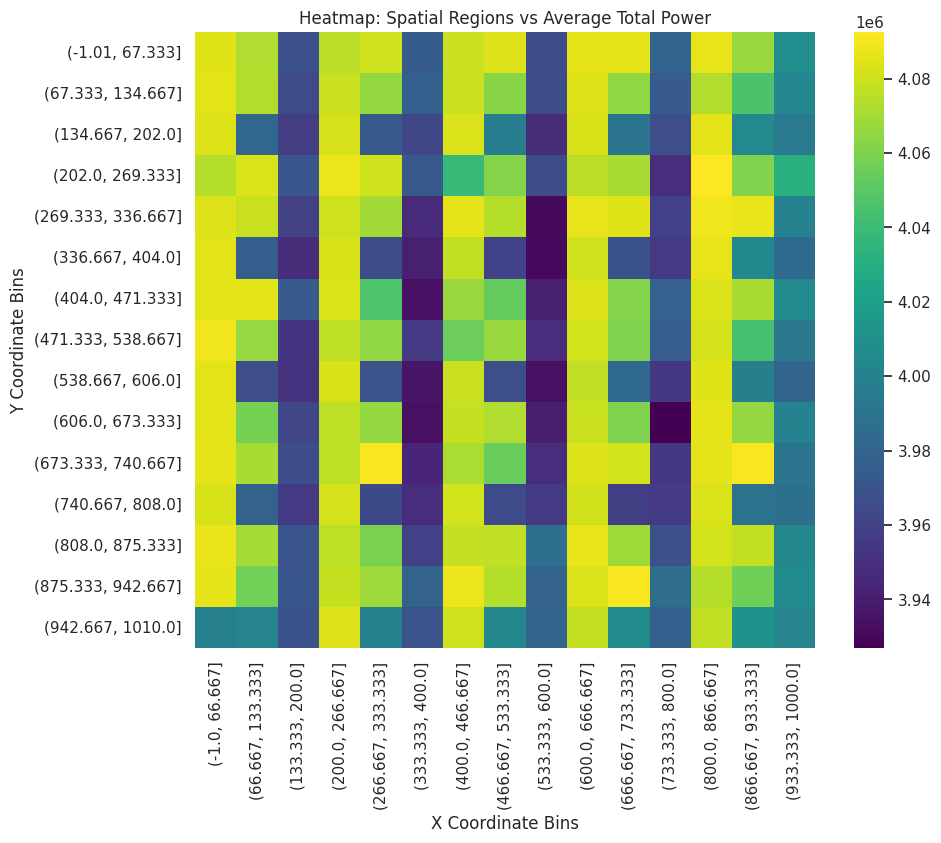

In [ ]:
#Plotting heatmap by melting the coordinate values( X1-X49 and Y1-Y49 )into long format, in order to make an overall analysis

records = []

for i in range(1, 50):
    temp = pd.DataFrame({
        'X': df[f'X{i}'],
        'Y': df[f'Y{i}'],
        'Total_Power': df['Total_Power']
    })
    records.append(temp)

df_long_xy = pd.concat(records, ignore_index=True)

# Create bins for X and Y
df_long_xy['X_bin'] = pd.cut(df_long_xy['X'], bins=15)
df_long_xy['Y_bin'] = pd.cut(df_long_xy['Y'], bins=15)

# Pivot table for heatmap
heatmap_data = df_long_xy.pivot_table(
    values='Total_Power',
    index='Y_bin',
    columns='X_bin',
    aggfunc='mean',
    observed=False
)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, cmap='viridis')
plt.title('Heatmap: Spatial Regions vs Average Total Power')
plt.xlabel('X Coordinate Bins')
plt.ylabel('Y Coordinate Bins')
plt.show()

## 8. Data Preparation

In [ ]:
# Drop qW as it is derived from power outputs, would cause data leakage
df_clean = df.drop(columns=['qW'])
print(f'Columns after dropping qW: {df_clean.shape[1]}')

Columns after dropping qW: 148


In [ ]:
# Separating features and target
# Using only spatial coordinates (X, Y) as input features as per research focus
spatial_cols = [c for c in df_clean.columns if c.startswith('X') or c.startswith('Y')]

X = df_clean[spatial_cols]
y = df_clean['Total_Power']

print(f'Feature matrix X: {X.shape}')
print(f'Target vector y:  {y.shape}')
print(f'\nFeatures used: {spatial_cols[:6]} ... (98 total)')

Feature matrix X: (4816, 98)
Target vector y:  (4816,)

Features used: ['X1', 'Y1', 'X2', 'Y2', 'X3', 'Y3'] ... (98 total)


In [ ]:
# Confirm no missing values in cleaned data
print(f'Missing values in X: {X.isnull().sum().sum()}')
print(f'Missing values in y: {y.isnull().sum()}')
print('\nData is ready for modelling!')

Missing values in X: 0
Missing values in y: 0

Data is ready for modelling!
